In [1]:
!git clone https://github.com/verlab/accelerated_features.git
%cd accelerated_features

!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q opencv-python-headless matplotlib numpy

Cloning into 'accelerated_features'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 167 (delta 74), reused 34 (delta 34), pack-reused 38 (from 1)
Receiving objects: 100% (167/167), 20.10 MiB | 181.00 KiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/accelerated_features


In [2]:
import os
print(os.listdir('/content/accelerated_features'))

['minimal_example.py', 'figs', 'LICENSE', 'requirements.txt', 'third_party', '.gitmodules', 'assets', 'weights', '.git', 'modules', 'README.md', 'notebooks', 'hubconf.py', '.gitignore', 'realtime_demo.py']


In [3]:
!cat /content/accelerated_features/minimal_example.py

"""
	"XFeat: Accelerated Features for Lightweight Image Matching, CVPR 2024."
	https://www.verlab.dcc.ufmg.br/descriptors/xfeat_cvpr24/

    Minimal example of how to use XFeat.
"""

import numpy as np
import os
import torch
import tqdm

from modules.xfeat import XFeat

os.environ['CUDA_VISIBLE_DEVICES'] = '' #Force CPU, comment for GPU

xfeat = XFeat()

#Random input
x = torch.randn(1,3,480,640)

#Simple inference with batch = 1
output = xfeat.detectAndCompute(x, top_k = 4096)[0]
print("----------------")
print("keypoints: ", output['keypoints'].shape)
print("descriptors: ", output['descriptors'].shape)
print("scores: ", output['scores'].shape)
print("----------------\n")

x = torch.randn(1,3,480,640)
# Stress test
for i in tqdm.tqdm(range(100), desc="Stress test on VGA resolution"):
	output = xfeat.detectAndCompute(x, top_k = 4096)

# Batched mode
x = torch.randn(4,3,480,640)
outputs = xfeat.detectAndCompute(x, top_k = 4096)
print("# detected features on each batch item:", [len(o['ke

In [4]:
import sys
sys.path.insert(0, '/content/accelerated_features')

from modules.xfeat import XFeat
print("XFeat imported successfully")

XFeat imported successfully


In [5]:
xfeat = XFeat()
print("XFeat model loaded")

loading weights from: /content/accelerated_features/modules/../weights/xfeat.pt
XFeat model loaded


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import cv2

dataset_dir = '/content/drive/MyDrive/rgb'
files = sorted(os.listdir(dataset_dir))
print(f"Total images: {len(files)}")
print(files[:5])

Total images: 613
['1305031452.791720.png', '1305031452.823674.png', '1305031452.859642.png', '1305031452.891726.png', '1305031452.923715.png']


In [8]:
import torch
import numpy as np

def load_tensor(filename):
    path = os.path.join(dataset_dir, filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0)  # (1, 3, H, W)
    return tensor, img_rgb

img1_tensor, img1_rgb = load_tensor(files[0])
img2_tensor, img2_rgb = load_tensor(files[1])

print("img1_tensor shape:", img1_tensor.shape)
print("img2_tensor shape:", img2_tensor.shape)

img1_tensor shape: torch.Size([1, 3, 480, 640])
img2_tensor shape: torch.Size([1, 3, 480, 640])


In [9]:
mkpts_0, mkpts_1 = xfeat.match_xfeat(img1_tensor, img2_tensor)

print("Matched keypoints in image 1:", mkpts_0.shape)
print("Matched keypoints in image 2:", mkpts_1.shape)

Matched keypoints in image 1: (1580, 2)
Matched keypoints in image 2: (1580, 2)


In [10]:
F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

inliers = int(mask.sum()) if mask is not None else 0
total_matches = len(mkpts_0)
inlier_ratio = inliers / total_matches if total_matches > 0 else 0

print("Matches:", total_matches)
print("Inliers:", inliers)
print("Inlier ratio: {:.2%}".format(inlier_ratio))

Matches: 1580
Inliers: 687
Inlier ratio: 43.48%


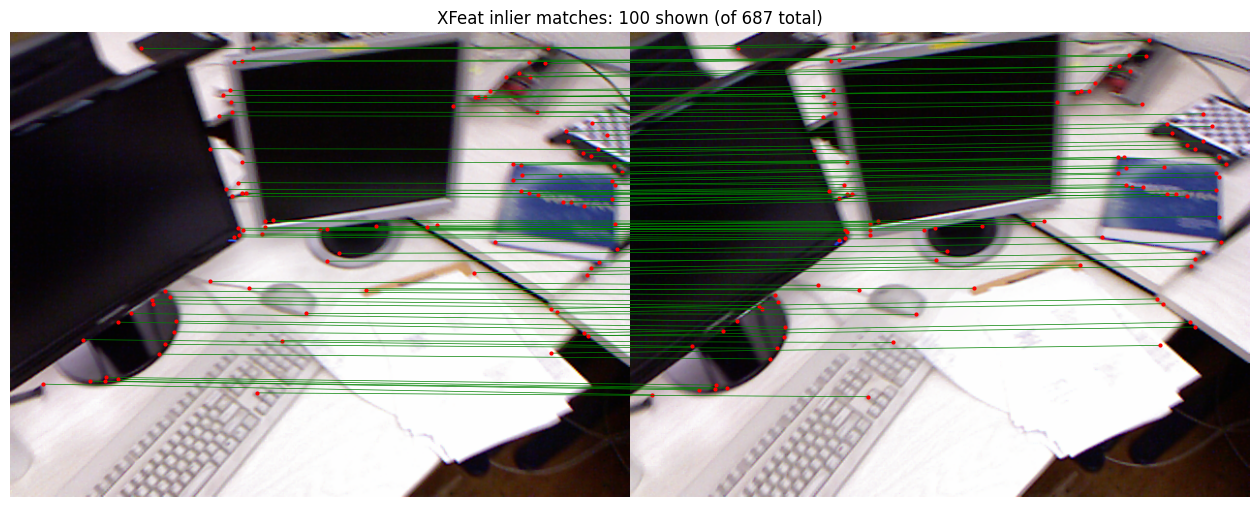

In [11]:
import matplotlib.pyplot as plt

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1_rgb
canvas[:h2, w1:w1+w2] = img2_rgb

inlier_idx = np.where(mask.ravel() == 1)[0]
draw_idx = inlier_idx[:100]

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
for idx in draw_idx:
    x1, y1 = mkpts_0[idx]
    x2, y2 = mkpts_1[idx]
    plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
    plt.plot(x1, y1, 'ro', markersize=2)
    plt.plot(x2 + w1, y2, 'ro', markersize=2)
plt.title(f"XFeat inlier matches: {len(draw_idx)} shown (of {inliers} total)")
plt.axis('off')
plt.show()

In [12]:
import time
import pandas as pd

results_xfeat = []
start_time = time.time()

for i in range(len(files) - 1):
    img1_tensor, _ = load_tensor(files[i])
    img2_tensor, _ = load_tensor(files[i+1])

    mkpts_0, mkpts_1 = xfeat.match_xfeat(img1_tensor, img2_tensor)

    num_matches = len(mkpts_0)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    results_xfeat.append({
        'pair_index': i,
        'frame1': files[i],
        'frame2': files[i+1],
        'num_matches': num_matches,
        'num_inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    })

    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Pair {i}/{len(files)-1} done | elapsed: {elapsed:.1f}s")

print("Batch run complete. Total time: {:.1f}s".format(time.time() - start_time))

Pair 0/612 done | elapsed: 0.3s
Pair 50/612 done | elapsed: 65.5s
Pair 100/612 done | elapsed: 135.6s
Pair 150/612 done | elapsed: 215.2s
Pair 200/612 done | elapsed: 284.6s
Pair 250/612 done | elapsed: 345.7s
Pair 300/612 done | elapsed: 414.4s
Pair 350/612 done | elapsed: 484.7s
Pair 400/612 done | elapsed: 559.3s
Pair 450/612 done | elapsed: 623.2s
Pair 500/612 done | elapsed: 695.2s
Pair 550/612 done | elapsed: 762.6s
Pair 600/612 done | elapsed: 832.6s
Batch run complete. Total time: 846.9s


In [13]:
df_xfeat = pd.DataFrame(results_xfeat)
csv_path = '/content/drive/MyDrive/xfeat_consecutive_pairs.csv'
df_xfeat.to_csv(csv_path, index=False)

print("Saved to:", csv_path)
print(df_xfeat.head())
print()
print("Summary stats:")
print(df_xfeat[['num_matches', 'num_inliers', 'inlier_ratio']].describe())


Saved to: /content/drive/MyDrive/xfeat_consecutive_pairs.csv
   pair_index                 frame1                 frame2  num_matches  \
0           0  1305031452.791720.png  1305031452.823674.png         1580   
1           1  1305031452.823674.png  1305031452.859642.png         1627   
2           2  1305031452.859642.png  1305031452.891726.png         1552   
3           3  1305031452.891726.png  1305031452.923715.png         1586   
4           4  1305031452.923715.png  1305031452.959701.png         1739   

   num_inliers  inlier_ratio  
0          687      0.434810  
1          689      0.423479  
2          620      0.399485  
3          739      0.465952  
4          901      0.518114  

Summary stats:
       num_matches  num_inliers  inlier_ratio
count   612.000000   612.000000    612.000000
mean   2100.982026  1062.423203      0.501128
std     341.856491   285.387208      0.078118
min    1384.000000   389.000000      0.250161
25%    1855.750000   864.750000      0.454418
50% 

In [14]:
robustness_dir = '/content/drive/MyDrive/assignment-3-dataset-low-texture-finding'

def load_tensor_resized(filename, max_dim=1280):
    path = os.path.join(robustness_dir, filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]
    scale = max_dim / max(h, w)
    if scale < 1:
        new_w, new_h = int(w * scale), int(h * scale)
        img_rgb = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0)
    return tensor

portrait_trolley_t = load_tensor_resized('portrait-trolley.jpeg')
trolley_45_rotated_t = load_tensor_resized('trolley-45-rotated.jpeg')
zoomed_trolley_t = load_tensor_resized('zoomed-trolley.jpeg')

portrait_wall_t = load_tensor_resized('portrait-wall.jpeg')
rotated_90_wall_t = load_tensor_resized('90-rotated-wall.jpeg')
zoomed_wall_t = load_tensor_resized('zoomed-wall.jpeg')

print("All robustness images loaded")

All robustness images loaded


In [15]:
def run_xfeat_test(img1_tensor, img2_tensor, label):
    mkpts_0, mkpts_1 = xfeat.match_xfeat(img1_tensor, img2_tensor)
    num_matches = len(mkpts_0)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    print(f"--- {label} ---")
    print(f"Matches: {num_matches} | Inliers: {num_inliers} | Inlier ratio: {inlier_ratio:.2%}")
    print()

    return {
        'test': label,
        'matches': num_matches,
        'inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    }

xfeat_robustness_results = []

xfeat_robustness_results.append(run_xfeat_test(portrait_trolley_t, trolley_45_rotated_t, "portrait-trolley vs trolley-45-rotated"))
xfeat_robustness_results.append(run_xfeat_test(portrait_trolley_t, zoomed_trolley_t, "portrait-trolley vs zoomed-trolley"))
xfeat_robustness_results.append(run_xfeat_test(portrait_wall_t, rotated_90_wall_t, "portrait-wall vs 90-rotated-wall"))
xfeat_robustness_results.append(run_xfeat_test(portrait_wall_t, zoomed_wall_t, "portrait-wall vs zoomed-wall"))


--- portrait-trolley vs trolley-45-rotated ---
Matches: 1931 | Inliers: 680 | Inlier ratio: 35.21%

--- portrait-trolley vs zoomed-trolley ---
Matches: 1556 | Inliers: 310 | Inlier ratio: 19.92%

--- portrait-wall vs 90-rotated-wall ---
Matches: 1442 | Inliers: 420 | Inlier ratio: 29.13%

--- portrait-wall vs zoomed-wall ---
Matches: 1160 | Inliers: 71 | Inlier ratio: 6.12%



In [16]:
xfeat_robustness_df = pd.DataFrame(xfeat_robustness_results)
xfeat_robustness_df.to_csv('/content/drive/MyDrive/xfeat_robustness_tests.csv', index=False)
print(xfeat_robustness_df)

                                     test  matches  inliers  inlier_ratio
0  portrait-trolley vs trolley-45-rotated     1931      680      0.352149
1      portrait-trolley vs zoomed-trolley     1556      310      0.199229
2        portrait-wall vs 90-rotated-wall     1442      420      0.291262
3            portrait-wall vs zoomed-wall     1160       71      0.061207


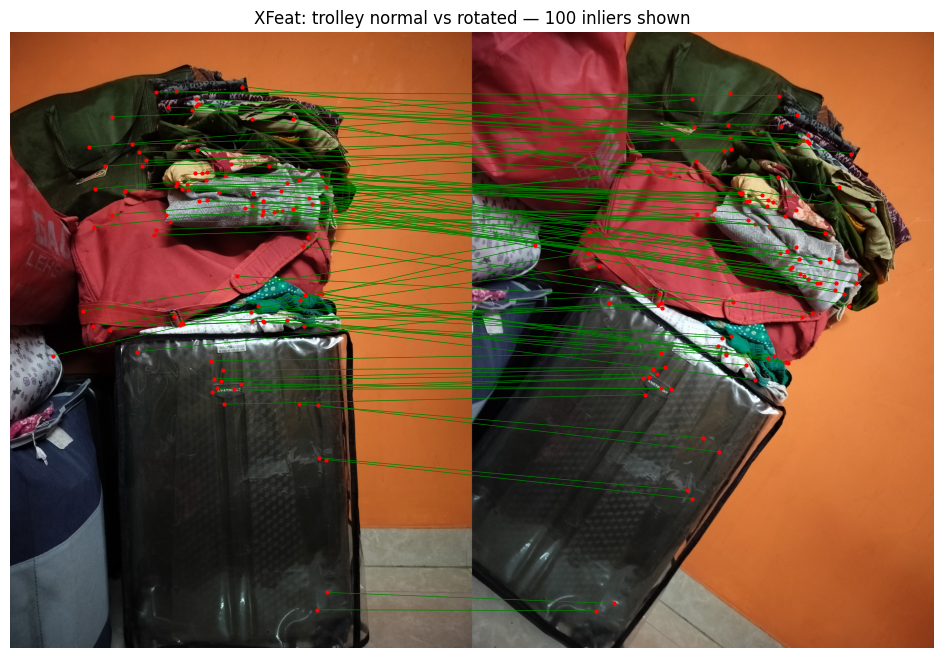

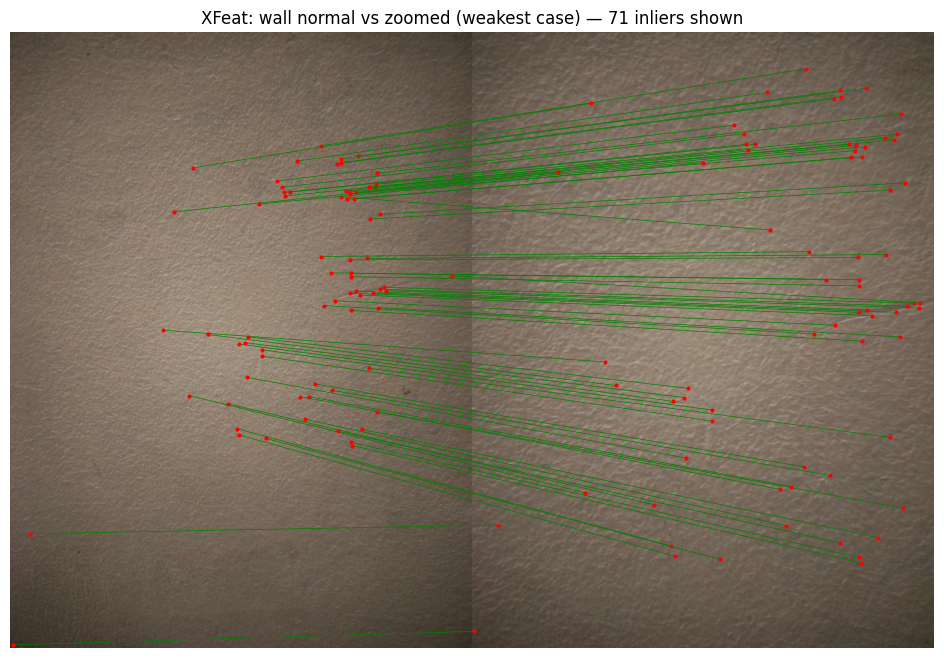

In [17]:
def draw_xfeat_matches(img1_tensor, img2_tensor, label, max_draw=100):
    mkpts_0, mkpts_1 = xfeat.match_xfeat(img1_tensor, img2_tensor)
    F, mask = cv2.findFundamentalMat(mkpts_0, mkpts_1, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

    img1_np = img1_tensor.squeeze(0).permute(1,2,0).numpy().astype(np.uint8)
    img2_np = img2_tensor.squeeze(0).permute(1,2,0).numpy().astype(np.uint8)

    h1, w1 = img1_np.shape[:2]
    h2, w2 = img2_np.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_np
    canvas[:h2, w1:w1+w2] = img2_np

    inlier_idx = np.where(mask.ravel() == 1)[0]
    draw_idx = inlier_idx[:max_draw]

    plt.figure(figsize=(16, 8))
    plt.imshow(canvas)
    for idx in draw_idx:
        x1, y1 = mkpts_0[idx]
        x2, y2 = mkpts_1[idx]
        plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
        plt.plot(x1, y1, 'ro', markersize=2)
        plt.plot(x2 + w1, y2, 'ro', markersize=2)
    plt.title(f"XFeat: {label} — {len(draw_idx)} inliers shown")
    plt.axis('off')
    plt.show()

draw_xfeat_matches(portrait_trolley_t, trolley_45_rotated_t, "trolley normal vs rotated")
draw_xfeat_matches(portrait_wall_t, zoomed_wall_t, "wall normal vs zoomed (weakest case)")